#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




In [1]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest




# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive

# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")

Mounted at /content/drive


In [2]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.

# TODO: Import necessary libraries

# TODO: Mount Google Drive

# TODO: Load the dataset into a DataFrame and preview the first few rows.


# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)

# TODO: Visualize the relationship between product variation and feedback

# TODO: Drop irrelevant columns ('date', 'rating')



# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column




# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer






# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets




# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier





# Hint: Use the `predict()` method to generate predictions for the test data.
# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.

# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report



# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
# Compare the results and discuss if the model is overfitting or underfitting.

# TODO: Compare training and testing accuracy and discuss model performance


# TODO: Import necessary libraries

In [3]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Load the dataset and preview the first few rows

df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


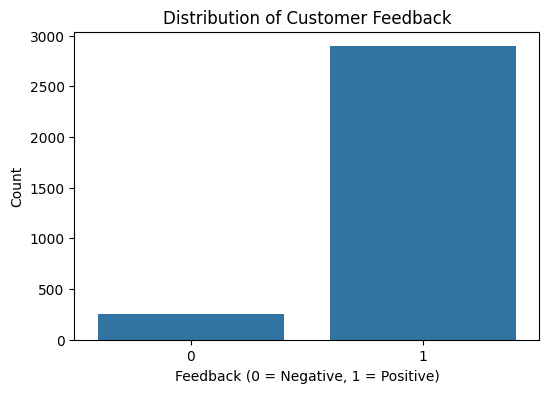

In [6]:
# Visualize the distribution of feedback

plt.figure(figsize=(6, 4))
sns.countplot(x='feedback', data=df)
plt.title('Distribution of Customer Feedback')
plt.xlabel('Feedback (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.show()

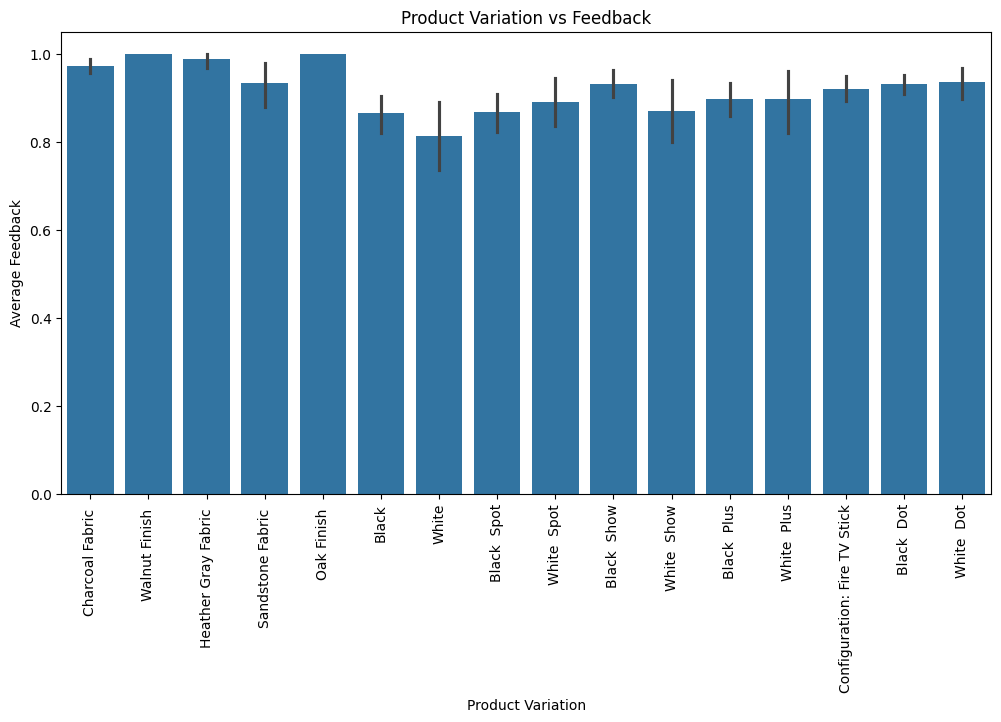

In [7]:
# Visualize the relationship between product variation and feedback

plt.figure(figsize=(12, 6))
sns.barplot(x='variation', y='feedback', data=df)
plt.xticks(rotation=90)
plt.title('Product Variation vs Feedback')
plt.xlabel('Product Variation')
plt.ylabel('Average Feedback')
plt.show()

In [8]:
# Drop irrelevant columns

df = df.drop(['date', 'rating'], axis=1)

df.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


In [9]:
# Perform one-hot encoding on the 'variation' column

variation_dummies = pd.get_dummies(df['variation'], prefix='variation')

df = pd.concat([df, variation_dummies], axis=1)

df = df.drop('variation', axis=1)

df.head()

,verified_reviews,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,Love my Echo!,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [10]:
# Tokenize the 'verified_reviews' column using CountVectorizer

vectorizer = CountVectorizer()

review_vectors = vectorizer.fit_transform(df['verified_reviews'].fillna(''))

review_df = pd.DataFrame(
    review_vectors.toarray(),
    columns=vectorizer.get_feature_names_out()
)

review_df.head()

,00,000,07,10,100,100x,11,1100sf,12,129,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# Combine tokenized reviews with the main dataframe

df = df.drop('verified_reviews', axis=1)

df = pd.concat([df.reset_index(drop=True), review_df], axis=1)

df.head()

,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,False,True,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Split the data into training and testing sets

feedback_positions = [i for i, col in enumerate(df.columns) if col == 'feedback']

# Use the first feedback column as the real target
y = df.iloc[:, feedback_positions[0]].astype(int)

# Remove all columns named feedback from the features
X = df.loc[:, df.columns != 'feedback']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (2520,)
y_test shape: (630,)


In [13]:
# Define and train a Random Forest Classifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


y_test shape: (630,)
y_pred shape: (630,)


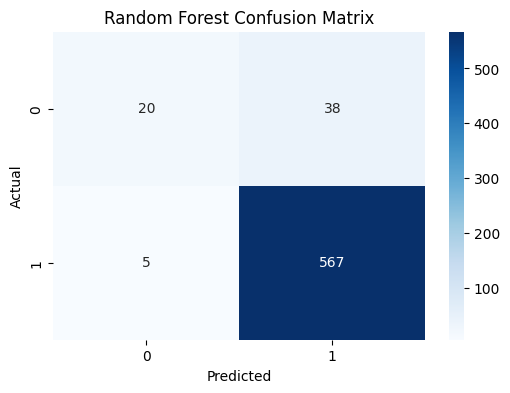

              precision    recall  f1-score   support

           0       0.80      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



In [14]:
# Rebuild and evaluate Random Forest model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

In [15]:
# Task 8: Analyze Model Performance

train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9964285714285714
Testing Accuracy: 0.9317460317460318


## Model Performance:
The Random Forest model achieved 99.64% training accuracy and 93.17% testing accuracy. The higher training accuracy shows that the model has some overfitting. However, the model still performs well on unseen test data with an accuracy of about 93%.

In [16]:
# Step 9: TF-IDF Feature Engineering

from sklearn.feature_extraction.text import TfidfVectorizer

# Reload the original review text
original_df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

# Replace missing reviews with empty text
reviews = original_df['verified_reviews'].fillna('')

# Convert reviews into TF-IDF numerical features
tfidf = TfidfVectorizer(stop_words='english')

X_tfidf = tfidf.fit_transform(reviews)

print("TF-IDF shape:", X_tfidf.shape)
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

TF-IDF shape: (3150, 3784)
Number of TF-IDF features: 3784


In [17]:
# Step 10: Split TF-IDF Data into Training and Testing Sets

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    original_df['feedback'],
    test_size=0.2,
    random_state=42,
    stratify=original_df['feedback']
)

print("Training data:", X_train_tfidf.shape)
print("Testing data:", X_test_tfidf.shape)

Training data: (2520, 3784)
Testing data: (630, 3784)


In [18]:
# Step 11: Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_tfidf, y_train_tfidf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [19]:
# Step 12: Evaluate Logistic Regression Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions
log_pred = log_model.predict(X_test_tfidf)
log_prob = log_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate evaluation metrics
print("Accuracy:", accuracy_score(y_test_tfidf, log_pred))
print("Precision:", precision_score(y_test_tfidf, log_pred))
print("Recall:", recall_score(y_test_tfidf, log_pred))
print("F1 Score:", f1_score(y_test_tfidf, log_pred))
print("ROC-AUC:", roc_auc_score(y_test_tfidf, log_prob))

Accuracy: 0.9206349206349206
Precision: 0.9205087440381559
Recall: 1.0
F1 Score: 0.9586092715231788
ROC-AUC: 0.9237529208574622


In [20]:
# Step 13: Train Support Vector Machine (SVM) Model

from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, random_state=42)

svm_model.fit(X_train_tfidf, y_train_tfidf)

print("SVM model trained successfully.")

SVM model trained successfully.


In [21]:
# Step 14: Evaluate SVM Model

# Make predictions
svm_pred = svm_model.predict(X_test_tfidf)
svm_prob = svm_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate evaluation metrics
print("Accuracy:", accuracy_score(y_test_tfidf, svm_pred))
print("Precision:", precision_score(y_test_tfidf, svm_pred))
print("Recall:", recall_score(y_test_tfidf, svm_pred))
print("F1 Score:", f1_score(y_test_tfidf, svm_pred))
print("ROC-AUC:", roc_auc_score(y_test_tfidf, svm_prob))

Accuracy: 0.9285714285714286
Precision: 0.9306451612903226
Recall: 0.9965457685664939
F1 Score: 0.9624687239366139
ROC-AUC: 0.9264790544888076


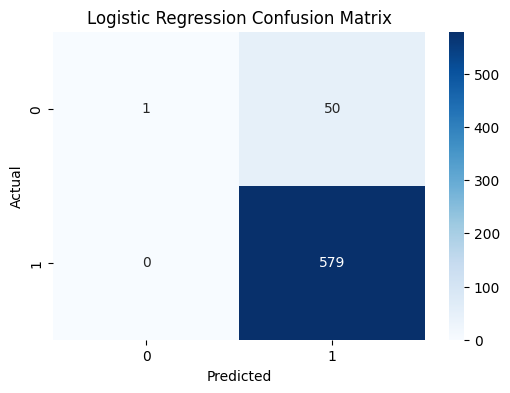

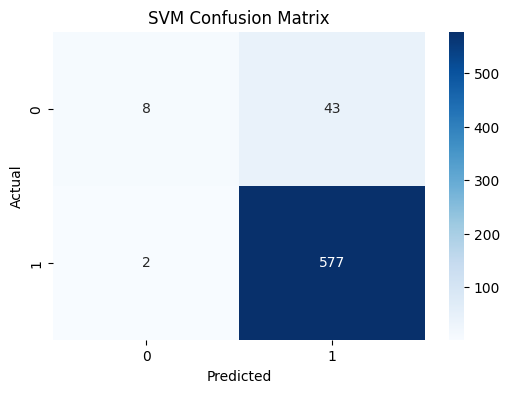

In [22]:
# Step 15: Confusion Matrices for Logistic Regression and SVM

from sklearn.metrics import confusion_matrix

# Logistic Regression
log_cm = confusion_matrix(y_test_tfidf, log_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SVM
svm_cm = confusion_matrix(y_test_tfidf, svm_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

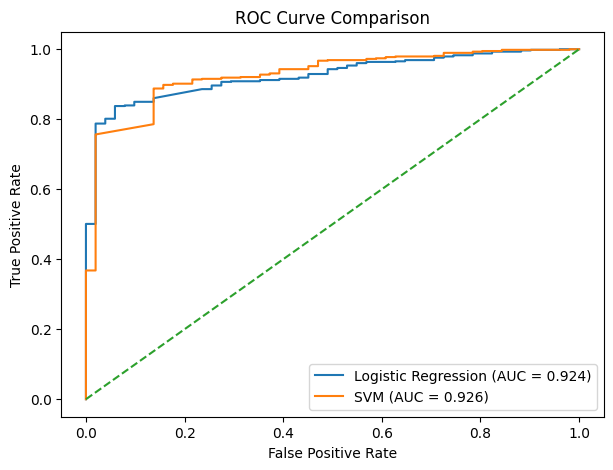

In [23]:
# Step 16: Plot ROC Curves

from sklearn.metrics import roc_curve

# Logistic Regression ROC
log_fpr, log_tpr, _ = roc_curve(y_test_tfidf, log_prob)

# SVM ROC
svm_fpr, svm_tpr, _ = roc_curve(y_test_tfidf, svm_prob)

plt.figure(figsize=(7, 5))

plt.plot(log_fpr, log_tpr,
         label='Logistic Regression (AUC = 0.924)')

plt.plot(svm_fpr, svm_tpr,
         label='SVM (AUC = 0.926)')

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [24]:
# Step 17: Optimize Logistic Regression Using Grid Search

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_log.fit(X_train_tfidf, y_train_tfidf)

print("Best Parameters:", grid_log.best_params_)
print("Best Cross-Validation F1 Score:", grid_log.best_score_)

Best Parameters: {'C': 10}
Best Cross-Validation F1 Score: 0.9673116989927408


In [25]:
# Step 18: Optimize SVM Using Grid Search

svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_param_grid,
    cv=5,
    scoring='f1'
)

grid_svm.fit(X_train_tfidf, y_train_tfidf)

print("Best Parameters:", grid_svm.best_params_)
print("Best Cross-Validation F1 Score:", grid_svm.best_score_)

Best Parameters: {'C': 10, 'kernel': 'linear'}
Best Cross-Validation F1 Score: 0.9661342743502634


In [26]:
!pip install gensim -q

print("Gensim installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 19.7 MB/s eta 0:00:00
Gensim installed successfully.


In [27]:
# Step 19: Create Word Embeddings Using Word2Vec

from gensim.models import Word2Vec

# Convert each review into a list of words
tokenized_reviews = [
    str(review).lower().split()
    for review in original_df['verified_reviews'].fillna('')
]

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Word2Vec model trained successfully.")
print("Vocabulary size:", len(word2vec_model.wv))

Word2Vec model trained successfully.
Vocabulary size: 3677


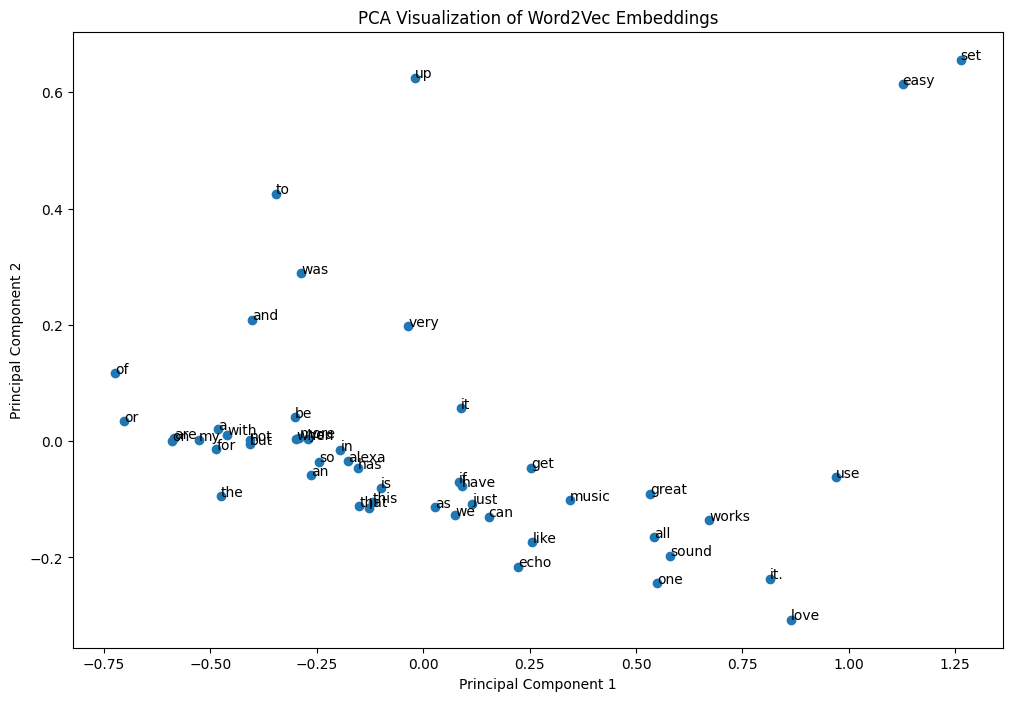

In [28]:
# Step 20: Visualize Word Embeddings Using PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select the first 50 words from the Word2Vec vocabulary
words = list(word2vec_model.wv.index_to_key)[:50]
word_vectors = [word2vec_model.wv[word] for word in words]

# Reduce word vectors from 100 dimensions to 2 dimensions
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(word_vectors)

# Create PCA visualization
plt.figure(figsize=(12, 8))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [29]:
# Step 21: Install Libraries for BERT

!pip install transformers datasets accelerate evaluate -q

print("BERT libraries installed successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00
BERT libraries installed successfully.


In [30]:
# Step 22: Load BERT Tokenizer and Model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT tokenizer and model loaded successfully.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT tokenizer and model loaded successfully.


In [31]:
# Step 23: Prepare Dataset for BERT

from datasets import Dataset

# Create dataframe for BERT
bert_df = original_df[['verified_reviews', 'feedback']].copy()

# Handle missing reviews
bert_df['verified_reviews'] = bert_df['verified_reviews'].fillna('')

# Rename columns for BERT
bert_df = bert_df.rename(
    columns={
        'verified_reviews': 'text',
        'feedback': 'label'
    }
)

# Split into training and testing data
bert_train_df, bert_test_df = train_test_split(
    bert_df,
    test_size=0.2,
    random_state=42,
    stratify=bert_df['label']
)

train_dataset = Dataset.from_pandas(
    bert_train_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    bert_test_df,
    preserve_index=False
)

print("BERT Training Data:", len(train_dataset))
print("BERT Testing Data:", len(test_dataset))

BERT Training Data: 2520
BERT Testing Data: 630


In [32]:
# Step 24: Tokenize Reviews for BERT

def tokenize_data(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_data, batched=True)
test_dataset = test_dataset.map(tokenize_data, batched=True)

print("BERT tokenization completed successfully.")
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Map:   0%|          | 0/2520 [00:00<?, ? examples/s]

Map:   0%|          | 0/630 [00:00<?, ? examples/s]

BERT tokenization completed successfully.
Training samples: 2520
Testing samples: 630


In [33]:
# Step 25: Fine-Tune BERT Model

from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

print("BERT fine-tuning completed successfully.")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.299180
100,0.178013
150,0.240976
200,0.161921
250,0.198941
300,0.185698


Step,Training Loss
50,0.299180
100,0.178013
150,0.240976
200,0.161921
250,0.198941
300,0.185698


BERT fine-tuning completed successfully.


In [34]:
# Step 26: Evaluate Fine-Tuned BERT Model

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Get predictions
bert_output = trainer.predict(test_dataset)

bert_logits = bert_output.predictions
bert_pred = np.argmax(bert_logits, axis=1)

# Convert logits to probabilities
bert_prob = np.exp(bert_logits) / np.exp(bert_logits).sum(axis=1, keepdims=True)
bert_prob_positive = bert_prob[:, 1]

# Actual labels
bert_true = np.array(test_dataset['label'])

# Evaluation results
print("BERT Accuracy:", accuracy_score(bert_true, bert_pred))
print("BERT Precision:", precision_score(bert_true, bert_pred))
print("BERT Recall:", recall_score(bert_true, bert_pred))
print("BERT F1 Score:", f1_score(bert_true, bert_pred))
print("BERT ROC-AUC:", roc_auc_score(bert_true, bert_prob_positive))

BERT Accuracy: 0.9492063492063492
BERT Precision: 0.9565943238731218
BERT Recall: 0.9896373056994818
BERT F1 Score: 0.9728353140916808
BERT ROC-AUC: 0.9737376816011378


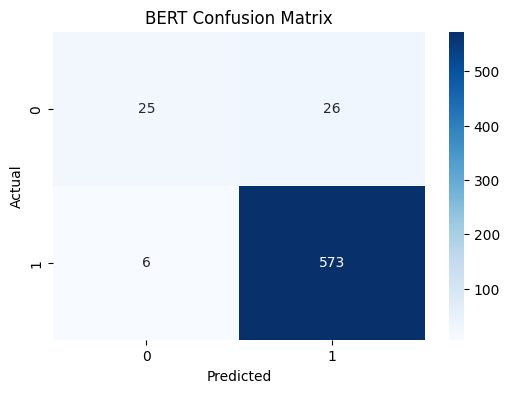

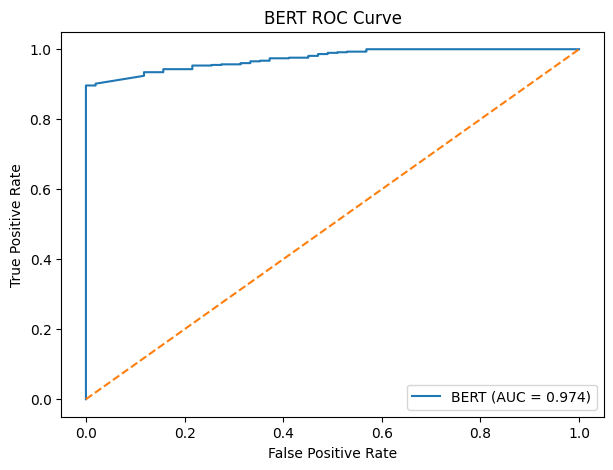

In [35]:
# Step 27: BERT Confusion Matrix and ROC Curve

from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm_bert = confusion_matrix(bert_true, bert_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues')
plt.title('BERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_bert, tpr_bert, _ = roc_curve(bert_true, bert_prob_positive)

plt.figure(figsize=(7, 5))
plt.plot(fpr_bert, tpr_bert, label='BERT (AUC = 0.974)')
plt.plot([0, 1], [0, 1], '--')
plt.title('BERT ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.9206     0.9205  1.0000    0.9586   0.9238
1                  SVM    0.9286     0.9306  0.9965    0.9625   0.9265
2                 BERT    0.9492     0.9566  0.9896    0.9728   0.9737


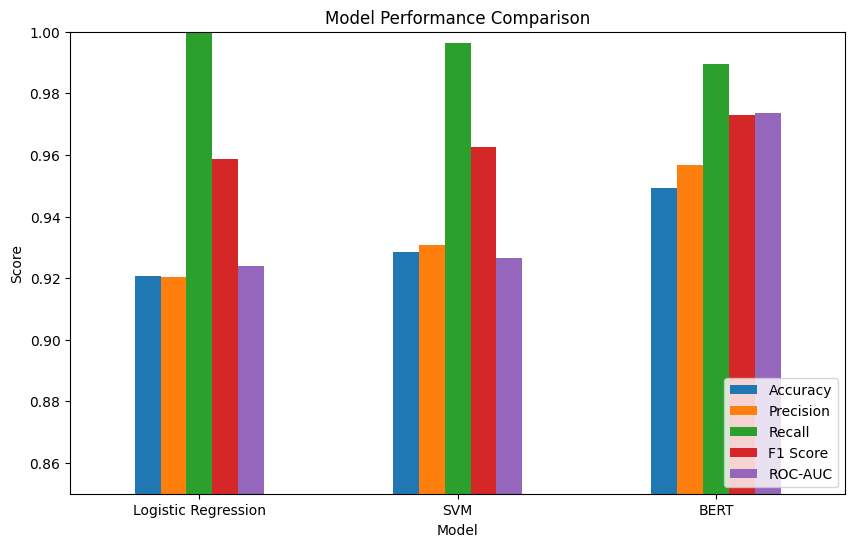

In [36]:
# Step 28: Compare Model Performance

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'BERT'],
    'Accuracy': [0.9206, 0.9286, 0.9492],
    'Precision': [0.9205, 0.9306, 0.9566],
    'Recall': [1.0000, 0.9965, 0.9896],
    'F1 Score': [0.9586, 0.9625, 0.9728],
    'ROC-AUC': [0.9238, 0.9265, 0.9737]
})

print(results)

results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## Step 29: Model Interpretation and Deployment



### Model Interpretation



I compared Logistic Regression, SVM, and BERT for customer review sentiment analysis. All three models performed well, but BERT gave the best overall results, with 94.92% accuracy and a 97.28% F1 score. Based on these results, I selected BERT as the best model.





### Deployment

This model could be used to automatically identify whether new customer reviews are positive or negative. This can help businesses understand customer feedback faster and identify areas that may need improvement.